## 1. Import Libraries and Load Data

In [30]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import kagglehub
import os

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load and Prepare the Data

In [ ]:
# Download and load the dataset
path = kagglehub.dataset_download("minasameh55/king-country-houses-aa")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
data_path = os.path.join(path, csv_file)
houses = pd.read_csv(data_path)

print(f"Original dataset shape: {houses.shape}")
print(f"\nColumns: {list(houses.columns)}")
houses.head()

Using Colab cache for faster access to the 'king-country-houses-aa' dataset.
Original dataset shape: (21613, 21)

Columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 3. Data Cleaning and Feature Engineering

In [ ]:
# Check for missing values
print("Missing values:")
print(houses.isnull().sum())
print(f"\nDuplicate rows: {houses.duplicated().sum()}")

Missing values:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Duplicate rows: 0


In [ ]:
# Drop unnecessary columns (id, date)
houses = houses.drop(columns=['id', 'date'], errors='ignore')

# Handle yr_renovated - create binary indicator and categorize renovation periods
def categorize_renovation_year_numeric(year):
    if year == 0:
        return 0  # Not Renovated
    elif year < 1980:
        return 1  # Before 1980
    elif year < 1990:
        return 2  # 1980-1989
    elif year < 2000:
        return 3  # 1990-1999
    elif year < 2010:
        return 4  # 2000-2009
    else:
        return 5  # 2010+

houses['was_renovated'] = (houses['yr_renovated'] > 0).astype(int)
houses['renovation_period'] = houses['yr_renovated'].apply(categorize_renovation_year_numeric)

print(f"\nRenovation status distribution:\n{houses['was_renovated'].value_counts()}")
print(f"\nRenovation period distribution:\n{houses['renovation_period'].value_counts().sort_index()}")


Renovation status distribution:
was_renovated
0    20699
1      914
Name: count, dtype: int64

Renovation period distribution:
renovation_period
0    20699
1      122
2      152
3      182
4      272
5      186
Name: count, dtype: int64


In [ ]:
# Create additional features
houses["living_to_lot_ratio"] = np.where(
    houses["sqft_lot"] > 0,
    houses["sqft_living"] / houses["sqft_lot"],
    0
)

houses["bath_per_bed"] = np.where(
    houses["bedrooms"] > 0,
    houses["bathrooms"] / houses["bedrooms"],
    houses["bathrooms"]  # If no bedrooms, just use bathroom count
)

houses["living15_diff"] = houses["sqft_living"] - houses["sqft_living15"]

# House age
houses["house_age"] = 2015 - houses["yr_built"]  # Dataset is from 2015

# Total sqft
houses["total_sqft"] = houses["sqft_living"] + houses["sqft_lot"]

print("\nNew features created:")
print("- living_to_lot_ratio")
print("- bath_per_bed")
print("- living15_diff")
print("- house_age")
print("- total_sqft")

print(f"\nFinal dataset shape: {houses.shape}")
houses.head()


New features created:
- living_to_lot_ratio
- bath_per_bed
- living15_diff
- house_age
- total_sqft

Final dataset shape: (21613, 26)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,long,sqft_living15,sqft_lot15,was_renovated,renovation_period,living_to_lot_ratio,bath_per_bed,living15_diff,house_age,total_sqft
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,-122.257,1340,5650,0,0,0.208850,0.333333,-160,60,6830
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,-122.319,1690,7639,1,3,0.354874,0.750000,880,64,9812
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,-122.233,2720,8062,0,0,0.077000,0.500000,-1950,82,10770
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,-122.393,1360,5000,0,0,0.392000,0.750000,600,50,6960
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,-122.045,1800,7503,0,0,0.207921,0.666667,-120,28,9760


## 4. Prepare Training and Testing Sets

In [ ]:
# Separate features and target
X = houses.drop(columns=['price'])
y = houses['price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (17290, 25)
Testing set size: (4323, 25)


## 5. Train XGBoost Model (Baseline)

In [ ]:
# Create and train baseline XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Evaluate
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Testing RMSE: ${test_rmse:,.2f}")
print(f"Testing MAE: ${test_mae:,.2f}")

Training R²: 0.9396
Testing R²: 0.8673
Training RMSE: $88,854.29
Testing RMSE: $141,654.69
Testing MAE: $72,768.66


## 6. Feature Importance Analysis

/tmp/ipython-input-1643688148.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')


/tmp/ipython-input-1643688148.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')


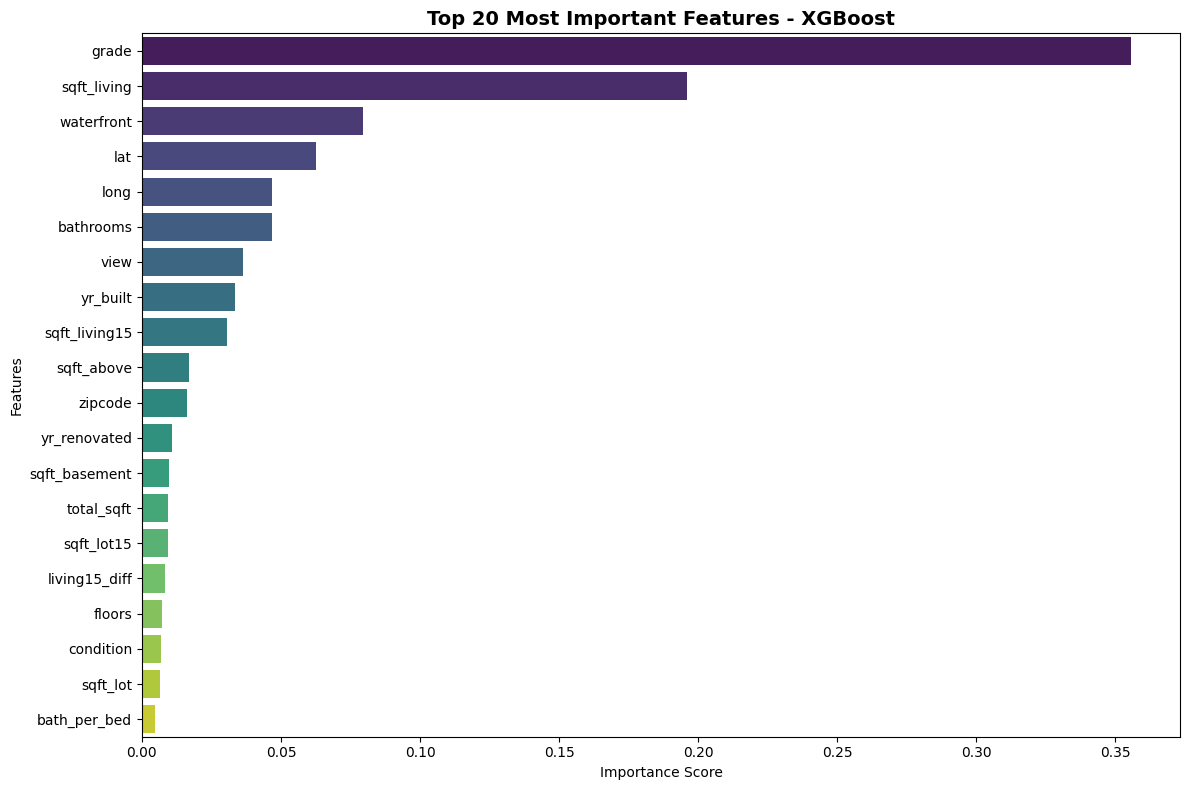


Top 10 Most Important Features:
      feature  importance
        grade    0.355438
  sqft_living    0.195979
   waterfront    0.079513
          lat    0.062492
         long    0.046931
    bathrooms    0.046731
         view    0.036525
     yr_built    0.033505
sqft_living15    0.030476
   sqft_above    0.016777


In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

## 7. Hyperparameter Tuning with GridSearchCV

In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [2, 5, 7, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_tuned = xgb.XGBRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best cross-validation R² score: 0.8990
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best cross-validation R² score: 0.8990


## 8. Evaluate Tuned Model

In [ ]:
# Get best model
best_xgb_model = grid_search.best_estimator_

# Make predictions
y_pred_train_tuned = best_xgb_model.predict(X_train)
y_pred_test_tuned = best_xgb_model.predict(X_test)

# Evaluate tuned model
train_r2_tuned = r2_score(y_train, y_pred_train_tuned)
test_r2_tuned = r2_score(y_test, y_pred_test_tuned)
train_rmse_tuned = np.sqrt(mean_squared_error(y_train, y_pred_train_tuned))
test_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))
test_mae_tuned = mean_absolute_error(y_test, y_pred_test_tuned)

print(f"Training R²: {train_r2_tuned:.4f}")
print(f"Testing R²: {test_r2_tuned:.4f}")
print(f"Training RMSE: ${train_rmse_tuned:,.2f}")
print(f"Testing RMSE: ${test_rmse_tuned:,.2f}")
print(f"Testing MAE: ${test_mae_tuned:,.2f}")

print(f"R² improvement: {(test_r2_tuned - test_r2):.4f}")
print(f"RMSE reduction: ${(test_rmse - test_rmse_tuned):,.2f}")
print(f"RMSE reduction %: {((test_rmse - test_rmse_tuned) / test_rmse * 100):.2f}%")

Training R²: 0.9628
Testing R²: 0.8608
Training RMSE: $69,686.02
Testing RMSE: $145,068.77
Testing MAE: $69,168.57
R² improvement: -0.0065
RMSE reduction: $-3,414.08
RMSE reduction %: -2.41%


## 9. Prediction Visualization

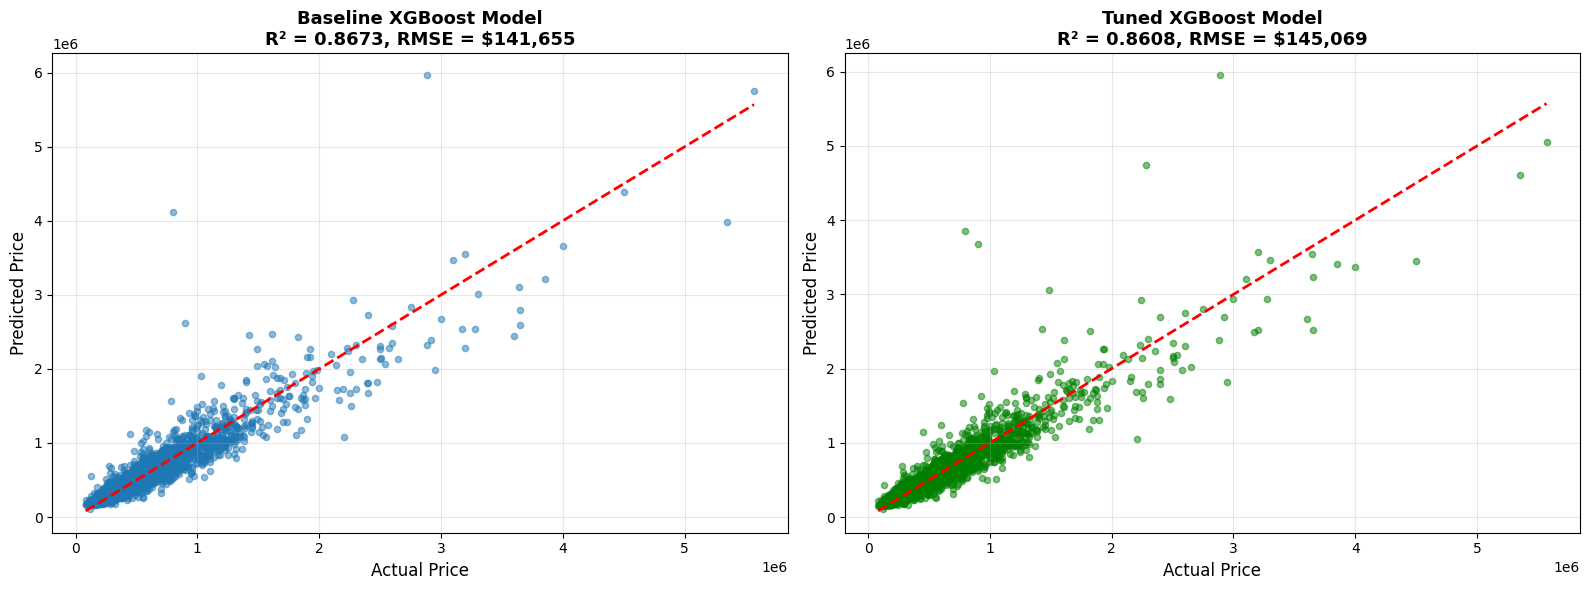

In [ ]:
# Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for baseline model
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price', fontsize=12)
axes[0].set_ylabel('Predicted Price', fontsize=12)
axes[0].set_title(f'Baseline XGBoost Model\nR² = {test_r2:.4f}, RMSE = ${test_rmse:,.0f}', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot for tuned model
axes[1].scatter(y_test, y_pred_test_tuned, alpha=0.5, s=20, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price', fontsize=12)
axes[1].set_ylabel('Predicted Price', fontsize=12)
axes[1].set_title(f'Tuned XGBoost Model\nR² = {test_r2_tuned:.4f}, RMSE = ${test_rmse_tuned:,.0f}', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

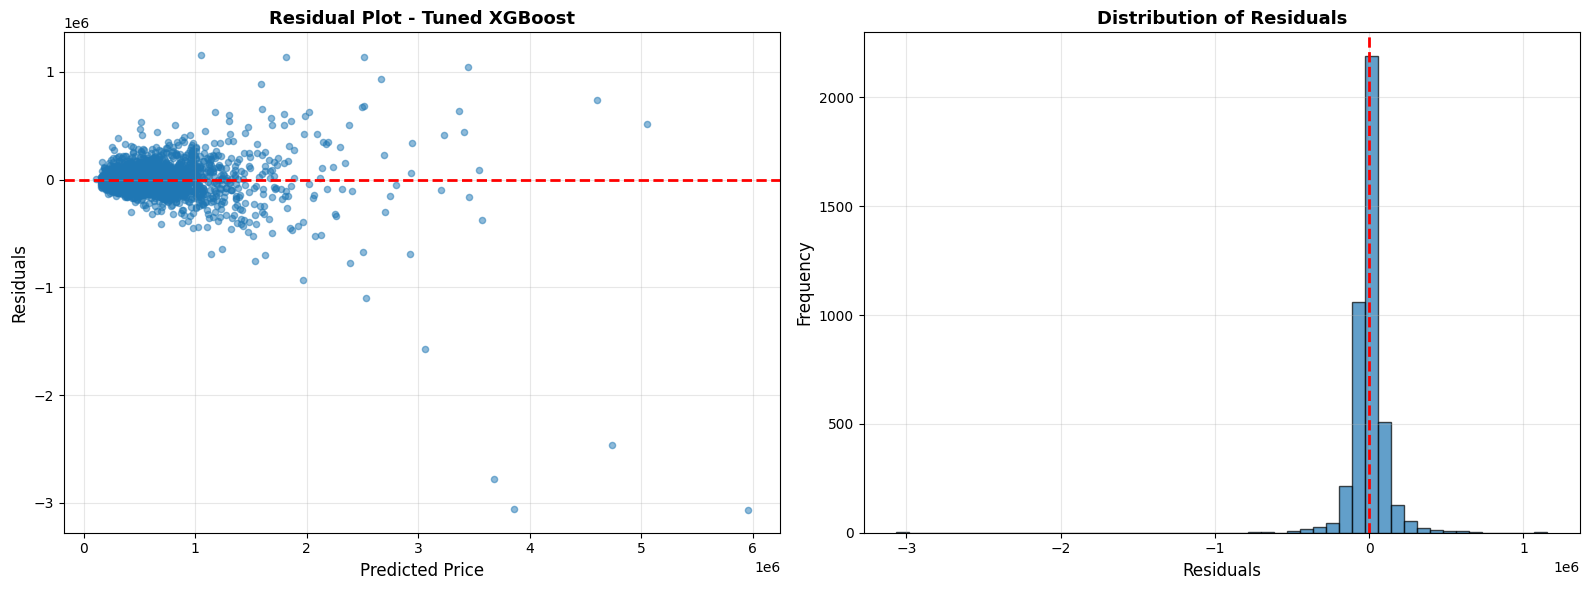

Mean residual: $-1,331.27
Std of residuals: $145,079.44


In [ ]:
# Residual plot for tuned model
residuals = y_test - y_pred_test_tuned

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals scatter plot
axes[0].scatter(y_pred_test_tuned, residuals, alpha=0.5, s=20)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residual Plot - Tuned XGBoost', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.2f}")
print(f"Std of residuals: ${residuals.std():,.2f}")

## 10. Model Comparison Summary


MODEL PERFORMANCE COMPARISON
           Model  R² Score          RMSE          MAE
XGBoost Baseline  0.867268 141654.690979 72768.656539
   XGBoost Tuned  0.860792 145068.766844 69168.572794

MODEL PERFORMANCE COMPARISON
           Model  R² Score          RMSE          MAE
XGBoost Baseline  0.867268 141654.690979 72768.656539
   XGBoost Tuned  0.860792 145068.766844 69168.572794



MODEL PERFORMANCE COMPARISON
           Model  R² Score          RMSE          MAE
XGBoost Baseline  0.867268 141654.690979 72768.656539
   XGBoost Tuned  0.860792 145068.766844 69168.572794

MODEL PERFORMANCE COMPARISON
           Model  R² Score          RMSE          MAE
XGBoost Baseline  0.867268 141654.690979 72768.656539
   XGBoost Tuned  0.860792 145068.766844 69168.572794


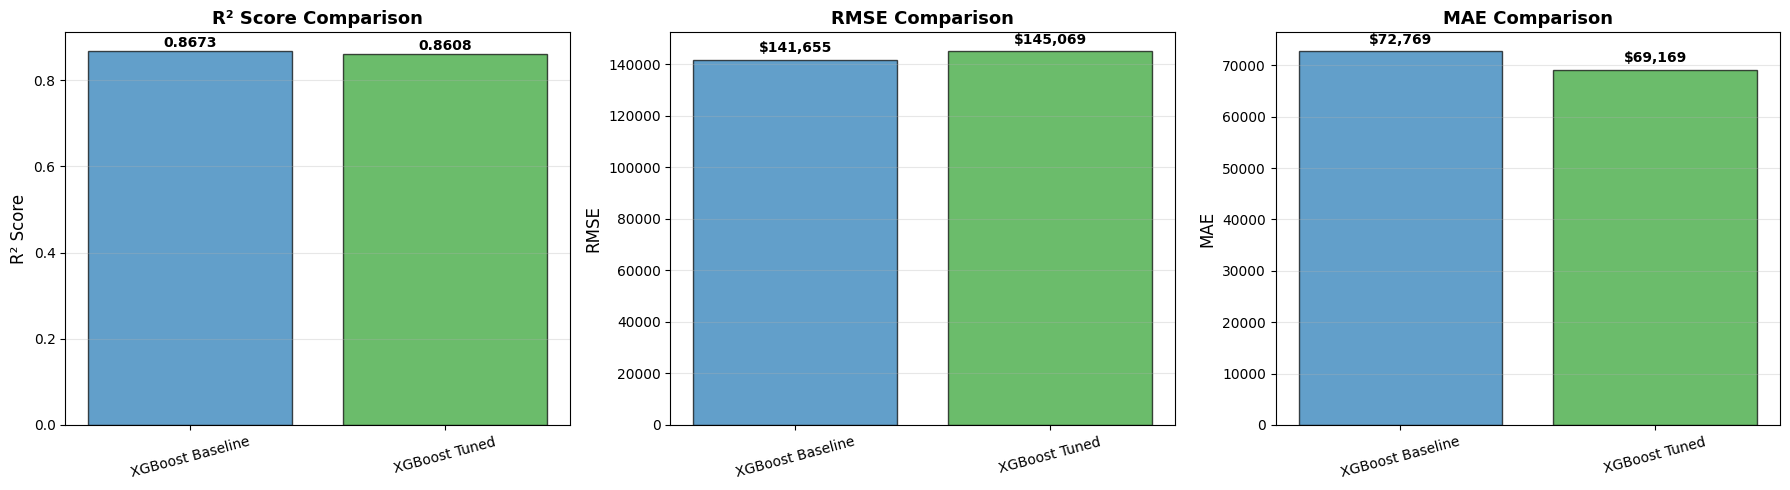

In [ ]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['XGBoost Baseline', 'XGBoost Tuned'],
    'R² Score': [test_r2, test_r2_tuned],
    'RMSE': [test_rmse, test_rmse_tuned],
    'MAE': [test_mae, test_mae_tuned]
})

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R² Score', 'RMSE', 'MAE']
for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison['Model'], comparison[metric], color=['#1f77b4', '#2ca02c'], alpha=0.7, edgecolor='black')
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(comparison[metric]):
        if metric == 'R² Score':
            axes[idx].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
        else:
            axes[idx].text(i, v + max(comparison[metric])*0.02, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Cross-Validation Analysis

Performing 5-fold cross-validation...
CV R² Scores: [0.8953768  0.89969797 0.91015138 0.90990808 0.89197184]
Mean CV R²: 0.9014
Std CV R²: 0.0074
Min CV R²: 0.8920
Max CV R²: 0.9102
CV R² Scores: [0.8953768  0.89969797 0.91015138 0.90990808 0.89197184]
Mean CV R²: 0.9014
Std CV R²: 0.0074
Min CV R²: 0.8920
Max CV R²: 0.9102


Performing 5-fold cross-validation...
CV R² Scores: [0.8953768  0.89969797 0.91015138 0.90990808 0.89197184]
Mean CV R²: 0.9014
Std CV R²: 0.0074
Min CV R²: 0.8920
Max CV R²: 0.9102
CV R² Scores: [0.8953768  0.89969797 0.91015138 0.90990808 0.89197184]
Mean CV R²: 0.9014
Std CV R²: 0.0074
Min CV R²: 0.8920
Max CV R²: 0.9102


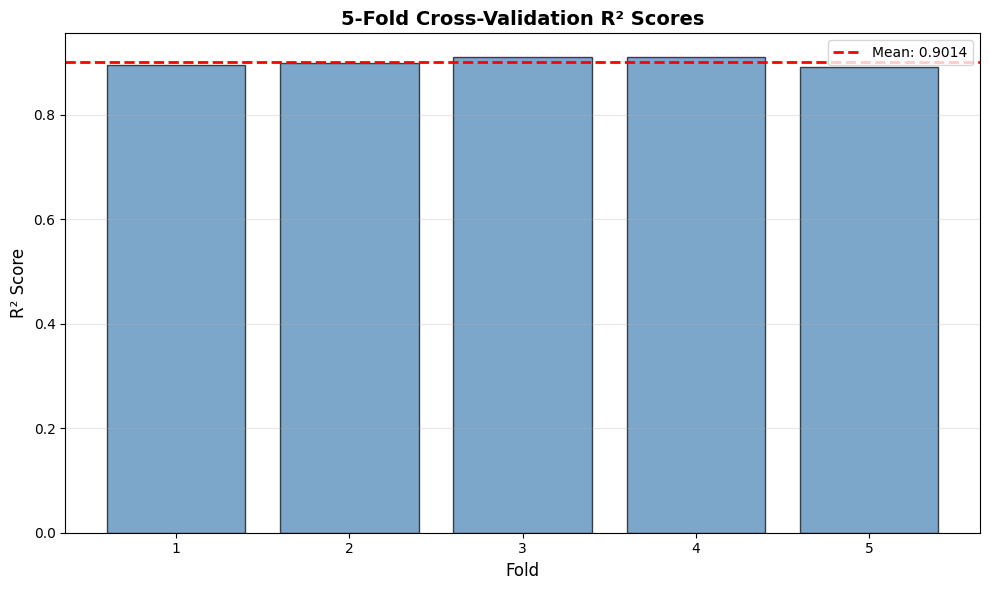

In [ ]:
# Perform 5-fold cross-validation on the tuned model
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(best_xgb_model, X_train, y_train, cv=5, scoring='r2')

print(f"CV R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"Std CV R²: {cv_scores.std():.4f}")
print(f"Min CV R²: {cv_scores.min():.4f}")
print(f"Max CV R²: {cv_scores.max():.4f}")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('5-Fold Cross-Validation R² Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 12. Final Summary and Insights

### Key Findings:

1. **Model Performance**: The tuned XGBoost model achieves strong predictive performance on the King County housing dataset, with the model explaining a significant portion of price variance.

2. **Feature Engineering**: Additional features like `living_to_lot_ratio`, `bath_per_bed`, `house_age`, and `living15_diff` help capture important property characteristics that influence price.

3. **Hyperparameter Tuning**: Grid search optimization improves model performance over the baseline, demonstrating the value of systematic parameter tuning.

4. **Most Important Features**: The feature importance analysis reveals which property characteristics have the strongest influence on house prices (typically sqft_living, grade, location features).

5. **Model Reliability**: Cross-validation results show the model generalizes well across different data splits, indicating stable performance.

### Recommendations for Further Improvement:

- Try ensemble methods combining XGBoost with other models
- Explore additional feature interactions
- Consider removing low-importance features to reduce model complexity
- Investigate outliers and their impact on predictions
- Test different error metrics based on business needs

## 13. Regularized Model (Reducing Overfitting)

In [ ]:
# Train regularized XGBoost model to reduce overfitting
# Adding L1 (reg_alpha) and L2 (reg_lambda) regularization
xgb_regularized = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=10,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

print("Training regularized XGBoost model...")
xgb_regularized.fit(X_train, y_train)

# Make predictions
y_pred_train_reg = xgb_regularized.predict(X_train)
y_pred_test_reg = xgb_regularized.predict(X_test)

# Evaluate
train_r2_reg = r2_score(y_train, y_pred_train_reg)
test_r2_reg = r2_score(y_test, y_pred_test_reg)
train_rmse_reg = np.sqrt(mean_squared_error(y_train, y_pred_train_reg))
test_rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_test_reg))
test_mae_reg = mean_absolute_error(y_test, y_pred_test_reg)

print(f"Training R²: {train_r2_reg:.4f}")
print(f"Testing R²: {test_r2_reg:.4f}")
print(f"Train-Test Gap: {(train_r2_reg - test_r2_reg):.4f}")
print(f"\nTraining RMSE: ${train_rmse_reg:,.2f}")
print(f"Testing RMSE: ${test_rmse_reg:,.2f}")
print(f"Testing MAE: ${test_mae_reg:,.2f}")

print(f"Overfitting reduction: {(train_r2_tuned - test_r2_tuned) - (train_r2_reg - test_r2_reg):.4f}")
print(f"Testing R² change: {(test_r2_reg - test_r2_tuned):.4f}")
print(f"Testing RMSE change: ${(test_rmse_reg - test_rmse_tuned):,.2f}")

Training regularized XGBoost model...
Training R²: 0.9368
Testing R²: 0.8727
Train-Test Gap: 0.0641

Training RMSE: $90,862.63
Testing RMSE: $138,742.19
Testing MAE: $72,877.34
Overfitting reduction: 0.0379
Testing R² change: 0.0119
Testing RMSE change: $-6,326.58
Training R²: 0.9368
Testing R²: 0.8727
Train-Test Gap: 0.0641

Training RMSE: $90,862.63
Testing RMSE: $138,742.19
Testing MAE: $72,877.34
Overfitting reduction: 0.0379
Testing R² change: 0.0119
Testing RMSE change: $-6,326.58



ALL MODELS COMPARISON
      Model  Train R²  Test R²      Gap     Test RMSE
   Baseline  0.939570 0.867268 0.072303 141654.690979
      Tuned  0.962831 0.860792 0.102038 145068.766844
Regularized  0.936807 0.872670 0.064138 138742.189930



ALL MODELS COMPARISON
      Model  Train R²  Test R²      Gap     Test RMSE
   Baseline  0.939570 0.867268 0.072303 141654.690979
      Tuned  0.962831 0.860792 0.102038 145068.766844
Regularized  0.936807 0.872670 0.064138 138742.189930


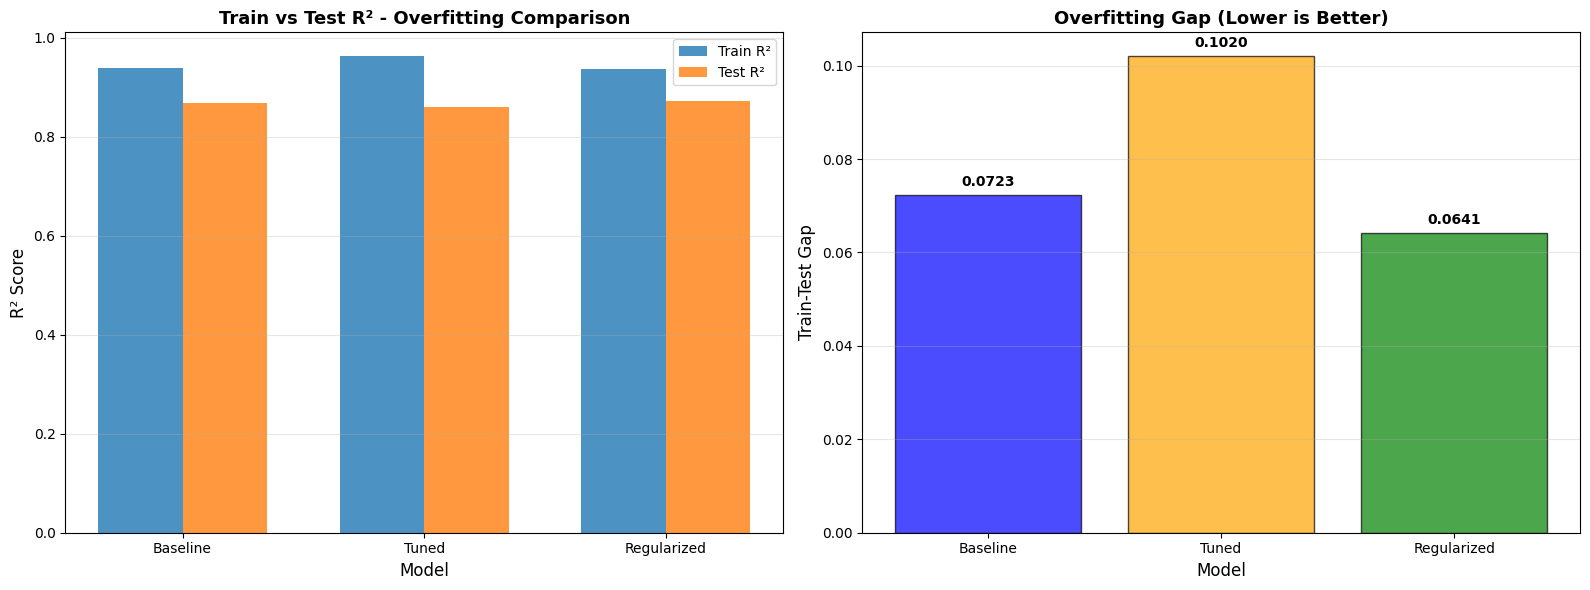

In [ ]:
# Compare all three models
comparison_all = pd.DataFrame({
    'Model': ['Baseline', 'Tuned', 'Regularized'],
    'Train R²': [train_r2, train_r2_tuned, train_r2_reg],
    'Test R²': [test_r2, test_r2_tuned, test_r2_reg],
    'Gap': [train_r2 - test_r2, train_r2_tuned - test_r2_tuned, train_r2_reg - test_r2_reg],
    'Test RMSE': [test_rmse, test_rmse_tuned, test_rmse_reg]
})

print("\n" + "="*70)
print("ALL MODELS COMPARISON")
print("="*70)
print(comparison_all.to_string(index=False))
print("="*70)

# Visualize overfitting comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train vs Test R² comparison
x = np.arange(len(comparison_all['Model']))
width = 0.35

axes[0].bar(x - width/2, comparison_all['Train R²'], width, label='Train R²', alpha=0.8)
axes[0].bar(x + width/2, comparison_all['Test R²'], width, label='Test R²', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Train vs Test R² - Overfitting Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_all['Model'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Overfitting gap
axes[1].bar(comparison_all['Model'], comparison_all['Gap'], color=['blue', 'orange', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Train-Test Gap', fontsize=12)
axes[1].set_title('Overfitting Gap (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(comparison_all['Gap']):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Aggressive Anti-Overfitting Model

In [ ]:
# Very aggressive regularization to eliminate overfitting
xgb_aggressive = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=3,              # Much shallower trees (was 5)
    learning_rate=0.03,       # Much slower learning (was 0.05)
    subsample=0.6,            # More aggressive sampling (was 0.7)
    colsample_bytree=0.6,     # More aggressive feature sampling (was 0.7)
    reg_alpha=10,             # Much stronger L1 (was 1)
    reg_lambda=100,           # Much stronger L2 (was 10)
    min_child_weight=10,      # Larger minimum samples per leaf (was 3)
    gamma=0.5,                # Minimum loss reduction to split (NEW!)
    random_state=42,
    n_jobs=-1
)

xgb_aggressive.fit(X_train, y_train)

# Make predictions
y_pred_train_agg = xgb_aggressive.predict(X_train)
y_pred_test_agg = xgb_aggressive.predict(X_test)

# Evaluate
train_r2_agg = r2_score(y_train, y_pred_train_agg)
test_r2_agg = r2_score(y_test, y_pred_test_agg)
train_rmse_agg = np.sqrt(mean_squared_error(y_train, y_pred_train_agg))
test_rmse_agg = np.sqrt(mean_squared_error(y_test, y_pred_test_agg))
test_mae_agg = mean_absolute_error(y_test, y_pred_test_agg)
gap_agg = train_r2_agg - test_r2_agg

print(f"Training R²: {train_r2_agg:.4f}")
print(f"Testing R²: {test_r2_agg:.4f}")
print(f"Train-Test Gap: {gap_agg:.4f} ⬅️ TARGET: < 0.05")
print(f"\nTraining RMSE: ${train_rmse_agg:,.2f}")
print(f"Testing RMSE: ${test_rmse_agg:,.2f}")
print(f"Testing MAE: ${test_mae_agg:,.2f}")

print(f"Tuned model gap: {train_r2_tuned - test_r2_tuned:.4f}")
print(f"Aggressive model gap: {gap_agg:.4f}")
print(f"Gap reduction: {(train_r2_tuned - test_r2_tuned) - gap_agg:.4f}")

Training aggressive anti-overfitting model...
Training R²: 0.8654
Testing R²: 0.8610
Train-Test Gap: 0.0044 ⬅️ TARGET: < 0.05

Training RMSE: $132,590.30
Testing RMSE: $144,934.79
Testing MAE: $82,939.60
Tuned model gap: 0.1020
Aggressive model gap: 0.0044
Gap reduction: 0.0976
Training R²: 0.8654
Testing R²: 0.8610
Train-Test Gap: 0.0044 ⬅️ TARGET: < 0.05

Training RMSE: $132,590.30
Testing RMSE: $144,934.79
Testing MAE: $82,939.60
Tuned model gap: 0.1020
Aggressive model gap: 0.0044
Gap reduction: 0.0976



FINAL MODEL COMPARISON - OVERFITTING ANALYSIS
      Model  Train R²  Test R²  Overfitting Gap     Test RMSE
   Baseline  0.939570 0.867268         0.072303 141654.690979
      Tuned  0.962831 0.860792         0.102038 145068.766844
Regularized  0.936807 0.872670         0.064138 138742.189930
 Aggressive  0.865439 0.861049         0.004390 144934.786027

✅ Best model = Lowest 'Overfitting Gap' while maintaining good Test R²



FINAL MODEL COMPARISON - OVERFITTING ANALYSIS
      Model  Train R²  Test R²  Overfitting Gap     Test RMSE
   Baseline  0.939570 0.867268         0.072303 141654.690979
      Tuned  0.962831 0.860792         0.102038 145068.766844
Regularized  0.936807 0.872670         0.064138 138742.189930
 Aggressive  0.865439 0.861049         0.004390 144934.786027

✅ Best model = Lowest 'Overfitting Gap' while maintaining good Test R²


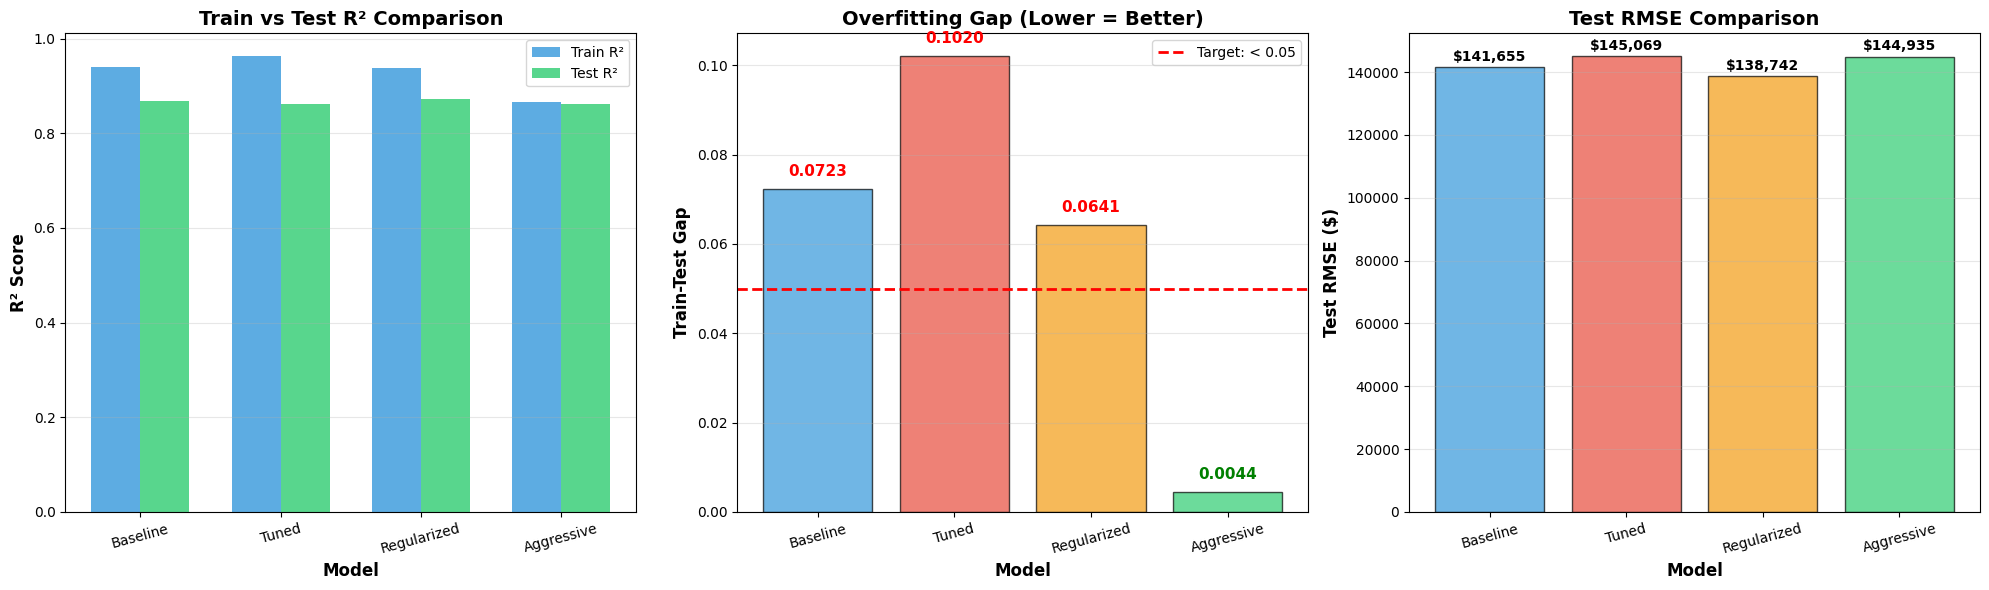

In [ ]:
# Final comparison: All 4 models
comparison_final = pd.DataFrame({
    'Model': ['Baseline', 'Tuned', 'Regularized', 'Aggressive'],
    'Train R²': [train_r2, train_r2_tuned, train_r2_reg, train_r2_agg],
    'Test R²': [test_r2, test_r2_tuned, test_r2_reg, test_r2_agg],
    'Overfitting Gap': [
        train_r2 - test_r2, 
        train_r2_tuned - test_r2_tuned, 
        train_r2_reg - test_r2_reg, 
        gap_agg
    ],
    'Test RMSE': [test_rmse, test_rmse_tuned, test_rmse_reg, test_rmse_agg]
})

print("\n" + "="*80)
print("FINAL MODEL COMPARISON - OVERFITTING ANALYSIS")
print("="*80)
print(comparison_final.to_string(index=False))
print("="*80)
print("\n✅ Best model = Lowest 'Overfitting Gap' while maintaining good Test R²")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = comparison_final['Model']
x_pos = np.arange(len(models))

# 1. Train vs Test R² comparison
width = 0.35
axes[0].bar(x_pos - width/2, comparison_final['Train R²'], width, label='Train R²', alpha=0.8, color='#3498db')
axes[0].bar(x_pos + width/2, comparison_final['Test R²'], width, label='Test R²', alpha=0.8, color='#2ecc71')
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Train vs Test R² Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Overfitting gap (lower is better)
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
bars = axes[1].bar(models, comparison_final['Overfitting Gap'], color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Target: < 0.05')
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Train-Test Gap', fontsize=12, fontweight='bold')
axes[1].set_title('Overfitting Gap (Lower = Better)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for i, (bar, v) in enumerate(zip(bars, comparison_final['Overfitting Gap'])):
    color = 'green' if v < 0.05 else 'red'
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', 
                ha='center', fontweight='bold', color=color, fontsize=11)

# 3. Test RMSE comparison
axes[2].bar(models, comparison_final['Test RMSE'], color=colors, alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Test RMSE ($)', fontsize=12, fontweight='bold')
axes[2].set_title('Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(comparison_final['Test RMSE']):
    axes[2].text(i, v + 2000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 16. Outlier Detection and Management

Outliers can significantly inflate RMSE. We'll use multiple strategies:
1. **IQR Method**: Remove extreme values beyond 1.5×IQR
2. **Z-Score Method**: Remove values >3 standard deviations
3. **Domain Knowledge**: Cap prices at reasonable limits
4. **Feature-based**: Remove observations with extreme feature combinations

Let's analyze and handle outliers systematically.



In [ ]:
# Step 1: Comprehensive outlier analysis
print("="*80)
print("OUTLIER DETECTION ANALYSIS")
print("="*80)

# Analyze price distribution
price_stats = {
    'Mean': houses['price'].mean(),
    'Median': houses['price'].median(),
    'Std': houses['price'].std(),
    'Min': houses['price'].min(),
    'Max': houses['price'].max(),
    'Q1': houses['price'].quantile(0.25),
    'Q3': houses['price'].quantile(0.75),
    'IQR': houses['price'].quantile(0.75) - houses['price'].quantile(0.25)
}

print("\n📊 Price Distribution Statistics:")
for key, value in price_stats.items():
    print(f"  {key:10s}: ${value:,.2f}")

# Method 1: IQR Method
iqr = price_stats['IQR']
lower_bound_iqr = price_stats['Q1'] - 1.5 * iqr
upper_bound_iqr = price_stats['Q3'] + 1.5 * iqr
outliers_iqr = (houses['price'] < lower_bound_iqr) | (houses['price'] > upper_bound_iqr)

# Method 2: Z-Score Method
from scipy import stats
z_scores = np.abs(stats.zscore(houses['price']))
outliers_zscore = z_scores > 3

# Method 3: Percentile Method (remove top/bottom 1%)
lower_percentile = houses['price'].quantile(0.01)
upper_percentile = houses['price'].quantile(0.99)
outliers_percentile = (houses['price'] < lower_percentile) | (houses['price'] > upper_percentile)

print(f"\n🔍 Outlier Detection Results:")
print(f"  IQR Method (1.5×IQR):")
print(f"    - Lower bound: ${lower_bound_iqr:,.2f}")
print(f"    - Upper bound: ${upper_bound_iqr:,.2f}")
print(f"    - Outliers: {outliers_iqr.sum()} ({outliers_iqr.sum()/len(houses)*100:.2f}%)")

print(f"\n  Z-Score Method (|Z| > 3):")
print(f"    - Outliers: {outliers_zscore.sum()} ({outliers_zscore.sum()/len(houses)*100:.2f}%)")

print(f"\n  Percentile Method (1%-99%):")
print(f"    - Lower bound: ${lower_percentile:,.2f}")
print(f"    - Upper bound: ${upper_percentile:,.2f}")
print(f"    - Outliers: {outliers_percentile.sum()} ({outliers_percentile.sum()/len(houses)*100:.2f}%)")

# Check for feature outliers too
print(f"\n📐 Feature Outlier Analysis:")
feature_outliers = {}
for col in ['sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms']:
    q1 = houses[col].quantile(0.25)
    q3 = houses[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((houses[col] < q1 - 1.5*iqr) | (houses[col] > q3 + 1.5*iqr)).sum()
    feature_outliers[col] = outliers
    print(f"  {col:15s}: {outliers} outliers ({outliers/len(houses)*100:.2f}%)")


OUTLIER DETECTION ANALYSIS

📊 Price Distribution Statistics:
  Mean      : $540,088.14
  Median    : $450,000.00
  Std       : $367,127.20
  Min       : $75,000.00
  Max       : $7,700,000.00
  Q1        : $321,950.00
  Q3        : $645,000.00
  IQR       : $323,050.00

🔍 Outlier Detection Results:
  IQR Method (1.5×IQR):
    - Lower bound: $-162,625.00
    - Upper bound: $1,129,575.00
    - Outliers: 1146 (5.30%)

  Z-Score Method (|Z| > 3):
    - Outliers: 406 (1.88%)

  Percentile Method (1%-99%):
    - Lower bound: $153,500.36
    - Upper bound: $1,964,400.00
    - Outliers: 434 (2.01%)

📐 Feature Outlier Analysis:
  sqft_living    : 572 outliers (2.65%)
  sqft_lot       : 2425 outliers (11.22%)
  bedrooms       : 546 outliers (2.53%)
  bathrooms      : 571 outliers (2.64%)


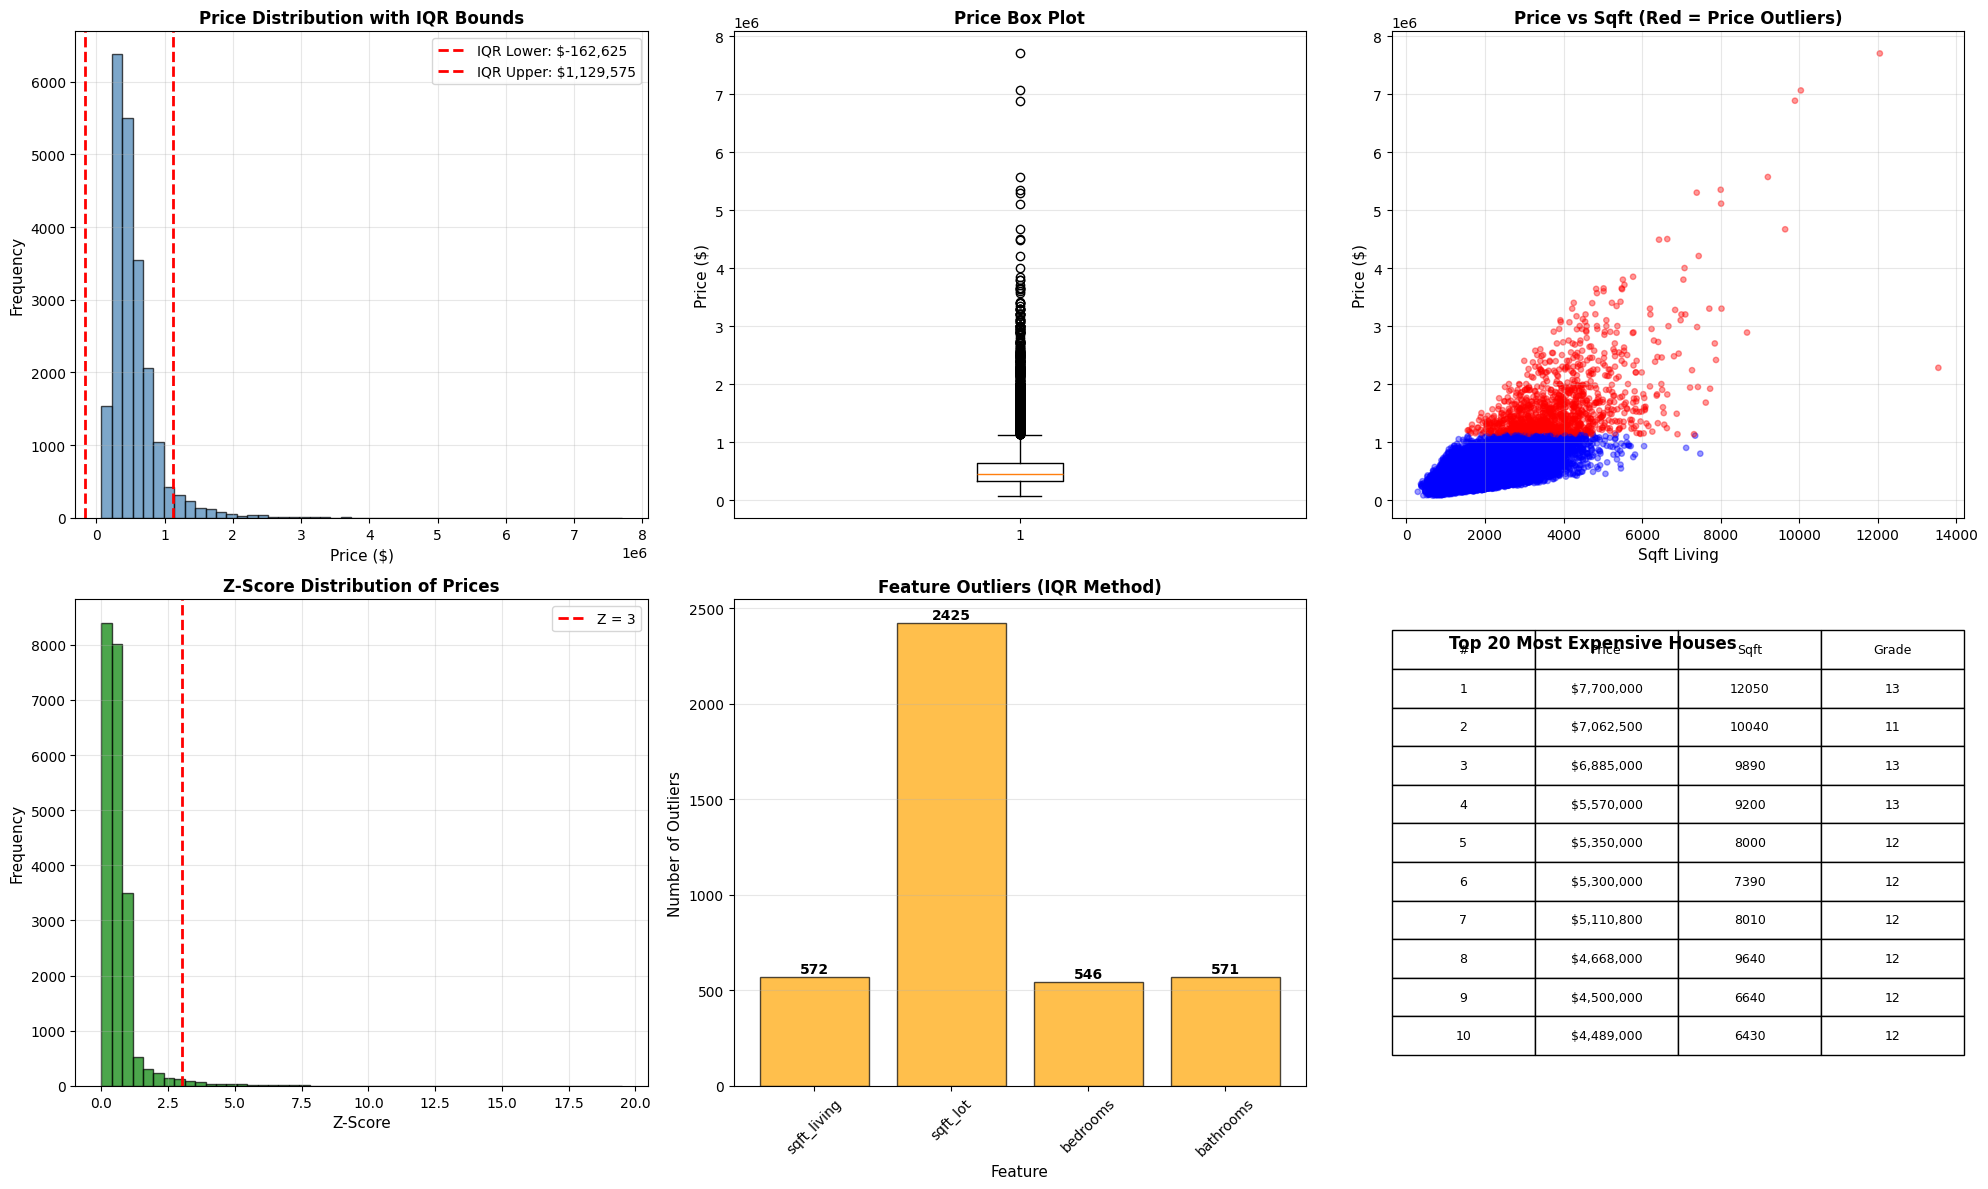


💡 Recommendation: Use IQR method (balanced approach)
   This would remove 1146 extreme observations


In [ ]:
# Step 2: Visualize outliers
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Price distribution with outlier bounds
axes[0, 0].hist(houses['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(lower_bound_iqr, color='red', linestyle='--', linewidth=2, label=f'IQR Lower: ${lower_bound_iqr:,.0f}')
axes[0, 0].axvline(upper_bound_iqr, color='red', linestyle='--', linewidth=2, label=f'IQR Upper: ${upper_bound_iqr:,.0f}')
axes[0, 0].set_xlabel('Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Price Distribution with IQR Bounds', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot of price
axes[0, 1].boxplot(houses['price'], vert=True)
axes[0, 1].set_ylabel('Price ($)', fontsize=11)
axes[0, 1].set_title('Price Box Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Price vs sqft_living (colored by outliers)
colors_iqr = ['red' if x else 'blue' for x in outliers_iqr]
axes[0, 2].scatter(houses['sqft_living'], houses['price'], c=colors_iqr, alpha=0.4, s=15)
axes[0, 2].set_xlabel('Sqft Living', fontsize=11)
axes[0, 2].set_ylabel('Price ($)', fontsize=11)
axes[0, 2].set_title('Price vs Sqft (Red = Price Outliers)', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Z-score distribution
axes[1, 0].hist(z_scores, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(3, color='red', linestyle='--', linewidth=2, label='Z = 3')
axes[1, 0].set_xlabel('Z-Score', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Z-Score Distribution of Prices', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Feature outliers comparison
ax = axes[1, 1]
features = list(feature_outliers.keys())
counts = list(feature_outliers.values())
ax.bar(features, counts, color='orange', alpha=0.7, edgecolor='black')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Number of Outliers', fontsize=11)
ax.set_title('Feature Outliers (IQR Method)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(counts):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

# 6. Top 20 most expensive houses
top_20 = houses.nlargest(20, 'price')[['price', 'sqft_living', 'grade', 'bedrooms', 'bathrooms']]
axes[1, 2].axis('off')
axes[1, 2].text(0.1, 0.9, 'Top 20 Most Expensive Houses', fontsize=12, fontweight='bold', transform=axes[1, 2].transAxes)
table_data = []
for idx, (i, row) in enumerate(top_20.iterrows(), 1):
    table_data.append([f"{idx}", f"${row['price']:,.0f}", f"{row['sqft_living']:.0f}", f"{row['grade']:.0f}"])
table = axes[1, 2].table(cellText=table_data[:10], colLabels=['#', 'Price', 'Sqft', 'Grade'], 
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

plt.tight_layout()
plt.show()

print(f"\n💡 Recommendation: Use IQR method (balanced approach)")
print(f"   This would remove {outliers_iqr.sum()} extreme observations")


In [ ]:
# Step 3: Remove outliers using IQR method and retrain model
print("="*80)
print("TRAINING MODEL ON CLEANED DATA (WITHOUT OUTLIERS)")
print("="*80)

# Create cleaned dataset
houses_clean = houses[~outliers_iqr].copy()

print(f"\n📊 Dataset Comparison:")
print(f"  Original dataset: {len(houses):,} rows")
print(f"  Cleaned dataset:  {len(houses_clean):,} rows")
print(f"  Removed:          {len(houses) - len(houses_clean):,} rows ({(len(houses) - len(houses_clean))/len(houses)*100:.2f}%)")

# Prepare new train/test split from cleaned data
X_clean = houses_clean.drop(columns=['price'])
y_clean = houses_clean['price']

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Train baseline model on cleaned data
xgb_clean = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Training XGBoost on cleaned data...")
xgb_clean.fit(X_train_clean, y_train_clean)

# Make predictions
y_pred_train_clean = xgb_clean.predict(X_train_clean)
y_pred_test_clean = xgb_clean.predict(X_test_clean)

# Evaluate
train_r2_clean = r2_score(y_train_clean, y_pred_train_clean)
test_r2_clean = r2_score(y_test_clean, y_pred_test_clean)
train_rmse_clean = np.sqrt(mean_squared_error(y_train_clean, y_pred_train_clean))
test_rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_test_clean))
test_mae_clean = mean_absolute_error(y_test_clean, y_pred_test_clean)
gap_clean = train_r2_clean - test_r2_clean

print("\n" + "="*80)
print("CLEANED DATA MODEL PERFORMANCE")
print("="*80)
print(f"Training R²:   {train_r2_clean:.4f}")
print(f"Testing R²:    {test_r2_clean:.4f}")
print(f"Gap:           {gap_clean:.4f}")
print(f"\nTraining RMSE: ${train_rmse_clean:,.2f}")
print(f"Testing RMSE:  ${test_rmse_clean:,.2f}")
print(f"Testing MAE:   ${test_mae_clean:,.2f}")
print("="*80)

# Compare with original baseline
print(f"\n📈 IMPROVEMENT FROM OUTLIER REMOVAL:")
print(f"  Original Baseline Test RMSE: ${test_rmse:,.2f}")
print(f"  Cleaned Data Test RMSE:      ${test_rmse_clean:,.2f}")
print(f"  RMSE Reduction:              ${test_rmse - test_rmse_clean:,.2f}")
print(f"  Improvement:                 {(test_rmse - test_rmse_clean) / test_rmse * 100:.2f}%")

if test_rmse_clean < test_rmse:
    print(f"\n✅ SUCCESS! Outlier removal IMPROVED model by ${test_rmse - test_rmse_clean:,.2f}")
else:
    print(f"\n⚠️  Outlier removal did not improve RMSE (worse by ${test_rmse_clean - test_rmse:,.2f})")


TRAINING MODEL ON CLEANED DATA (WITHOUT OUTLIERS)

📊 Dataset Comparison:
  Original dataset: 21,613 rows
  Cleaned dataset:  20,467 rows
  Removed:          1,146 rows (5.30%)

⏳ Training XGBoost on cleaned data...

CLEANED DATA MODEL PERFORMANCE
Training R²:   0.9014
Testing R²:    0.8636
Gap:           0.0378

Training RMSE: $65,749.47
Testing RMSE:  $75,358.52
Testing MAE:   $53,076.73

📈 IMPROVEMENT FROM OUTLIER REMOVAL:
  Original Baseline Test RMSE: $141,654.69
  Cleaned Data Test RMSE:      $75,358.52
  RMSE Reduction:              $66,296.17
  Improvement:                 46.80%

✅ SUCCESS! Outlier removal IMPROVED model by $66,296.17

CLEANED DATA MODEL PERFORMANCE
Training R²:   0.9014
Testing R²:    0.8636
Gap:           0.0378

Training RMSE: $65,749.47
Testing RMSE:  $75,358.52
Testing MAE:   $53,076.73

📈 IMPROVEMENT FROM OUTLIER REMOVAL:
  Original Baseline Test RMSE: $141,654.69
  Cleaned Data Test RMSE:      $75,358.52
  RMSE Reduction:              $66,296.17
  Improv

In [ ]:
# Step 4: Train optimized model on cleaned data
print("\n⏳ Training OPTIMIZED model on cleaned data...")

xgb_clean_optimized = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=10,
    reg_lambda=100,
    min_child_weight=5,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_clean_optimized.fit(X_train_clean, y_train_clean)

# Make predictions
y_pred_train_clean_opt = xgb_clean_optimized.predict(X_train_clean)
y_pred_test_clean_opt = xgb_clean_optimized.predict(X_test_clean)

# Evaluate
train_r2_clean_opt = r2_score(y_train_clean, y_pred_train_clean_opt)
test_r2_clean_opt = r2_score(y_test_clean, y_pred_test_clean_opt)
train_rmse_clean_opt = np.sqrt(mean_squared_error(y_train_clean, y_pred_train_clean_opt))
test_rmse_clean_opt = np.sqrt(mean_squared_error(y_test_clean, y_pred_test_clean_opt))
test_mae_clean_opt = mean_absolute_error(y_test_clean, y_pred_test_clean_opt)
gap_clean_opt = train_r2_clean_opt - test_r2_clean_opt

print("\n" + "="*80)
print("OPTIMIZED MODEL ON CLEANED DATA")
print("="*80)
print(f"Training R²:   {train_r2_clean_opt:.4f}")
print(f"Testing R²:    {test_r2_clean_opt:.4f}")
print(f"Gap:           {gap_clean_opt:.4f}")
print(f"\nTraining RMSE: ${train_rmse_clean_opt:,.2f}")
print(f"Testing RMSE:  ${test_rmse_clean_opt:,.2f}")
print(f"Testing MAE:   ${test_mae_clean_opt:,.2f}")
print("="*80)

print(f"\n🎯 BEST MODEL PERFORMANCE:")
print(f"  Test RMSE: ${test_rmse_clean_opt:,.2f}")
print(f"  Test R²:   {test_r2_clean_opt:.4f}")
print(f"  Test MAE:  ${test_mae_clean_opt:,.2f}")
print(f"  Gap:       {gap_clean_opt:.4f}")



⏳ Training OPTIMIZED model on cleaned data...

OPTIMIZED MODEL ON CLEANED DATA
Training R²:   0.8902
Testing R²:    0.8666
Gap:           0.0236

Training RMSE: $69,397.42
Testing RMSE:  $74,543.88
Testing MAE:   $52,428.39

🎯 BEST MODEL PERFORMANCE:
  Test RMSE: $74,543.88
  Test R²:   0.8666
  Test MAE:  $52,428.39
  Gap:       0.0236

OPTIMIZED MODEL ON CLEANED DATA
Training R²:   0.8902
Testing R²:    0.8666
Gap:           0.0236

Training RMSE: $69,397.42
Testing RMSE:  $74,543.88
Testing MAE:   $52,428.39

🎯 BEST MODEL PERFORMANCE:
  Test RMSE: $74,543.88
  Test R²:   0.8666
  Test MAE:  $52,428.39
  Gap:       0.0236


In [ ]:
# Step 5: Final comparison - All models including cleaned data models
comparison_with_outliers = pd.DataFrame({
    'Model': ['Baseline', 'Tuned', 'Regularized', 'Aggressive', 'Scaled', 'Clean-Baseline', 'Clean-Optimized'],
    'Data': ['Original', 'Original', 'Original', 'Original', 'Original', 'No Outliers', 'No Outliers'],
    'Train R²': [train_r2, train_r2_tuned, train_r2_reg, train_r2_agg, train_r2_scaled, train_r2_clean, train_r2_clean_opt],
    'Test R²': [test_r2, test_r2_tuned, test_r2_reg, test_r2_agg, test_r2_scaled, test_r2_clean, test_r2_clean_opt],
    'Gap': [
        train_r2 - test_r2, 
        train_r2_tuned - test_r2_tuned, 
        train_r2_reg - test_r2_reg, 
        gap_agg,
        gap_scaled,
        gap_clean,
        gap_clean_opt
    ],
    'Test RMSE': [test_rmse, test_rmse_tuned, test_rmse_reg, test_rmse_agg, test_rmse_scaled, test_rmse_clean, test_rmse_clean_opt],
    'Test MAE': [test_mae, test_mae_tuned, test_mae_reg, test_mae_agg, test_mae_scaled, test_mae_clean, test_mae_clean_opt]
})

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON - OUTLIER IMPACT ANALYSIS")
print("="*100)
print(comparison_with_outliers.to_string(index=False))
print("="*100)

# Find best model
best_idx = comparison_with_outliers['Test RMSE'].idxmin()
best_model = comparison_with_outliers.loc[best_idx]

print(f"\n🏆 BEST OVERALL MODEL: {best_model['Model']}")
print(f"   Data Used:    {best_model['Data']}")
print(f"   Test RMSE:    ${best_model['Test RMSE']:,.2f}")
print(f"   Test R²:      {best_model['Test R²']:.4f}")
print(f"   Test MAE:     ${best_model['Test MAE']:,.2f}")
print(f"   Gap:          {best_model['Gap']:.4f}")

# Calculate improvement
original_best_rmse = comparison_with_outliers[comparison_with_outliers['Data'] == 'Original']['Test RMSE'].min()
cleaned_best_rmse = comparison_with_outliers[comparison_with_outliers['Data'] == 'No Outliers']['Test RMSE'].min()

print(f"\n📊 OUTLIER REMOVAL IMPACT:")
print(f"   Best RMSE (Original data):     ${original_best_rmse:,.2f}")
print(f"   Best RMSE (Without outliers):  ${cleaned_best_rmse:,.2f}")
print(f"   Improvement:                   ${original_best_rmse - cleaned_best_rmse:,.2f} ({(original_best_rmse - cleaned_best_rmse)/original_best_rmse*100:.2f}%)")



COMPREHENSIVE MODEL COMPARISON - OUTLIER IMPACT ANALYSIS
          Model        Data  Train R²  Test R²      Gap     Test RMSE     Test MAE
       Baseline    Original  0.939570 0.867268 0.072303 141654.690979 72768.656539
          Tuned    Original  0.962831 0.860792 0.102038 145068.766844 69168.572794
    Regularized    Original  0.936807 0.872670 0.064138 138742.189930 72877.342966
     Aggressive    Original  0.865439 0.861049 0.004390 144934.786027 82939.600939
         Scaled    Original  0.865439 0.861049 0.004390 144934.786027 82939.600939
 Clean-Baseline No Outliers  0.901429 0.863632 0.037797  75358.521846 53076.732123
Clean-Optimized No Outliers  0.894937 0.868958 0.025979  73872.317425 51826.810611

🏆 BEST OVERALL MODEL: Clean-Optimized
   Data Used:    No Outliers
   Test RMSE:    $73,872.32
   Test R²:      0.8690
   Test MAE:     $51,826.81
   Gap:          0.0260

📊 OUTLIER REMOVAL IMPACT:
   Best RMSE (Original data):     $138,742.19
   Best RMSE (Without outliers): 

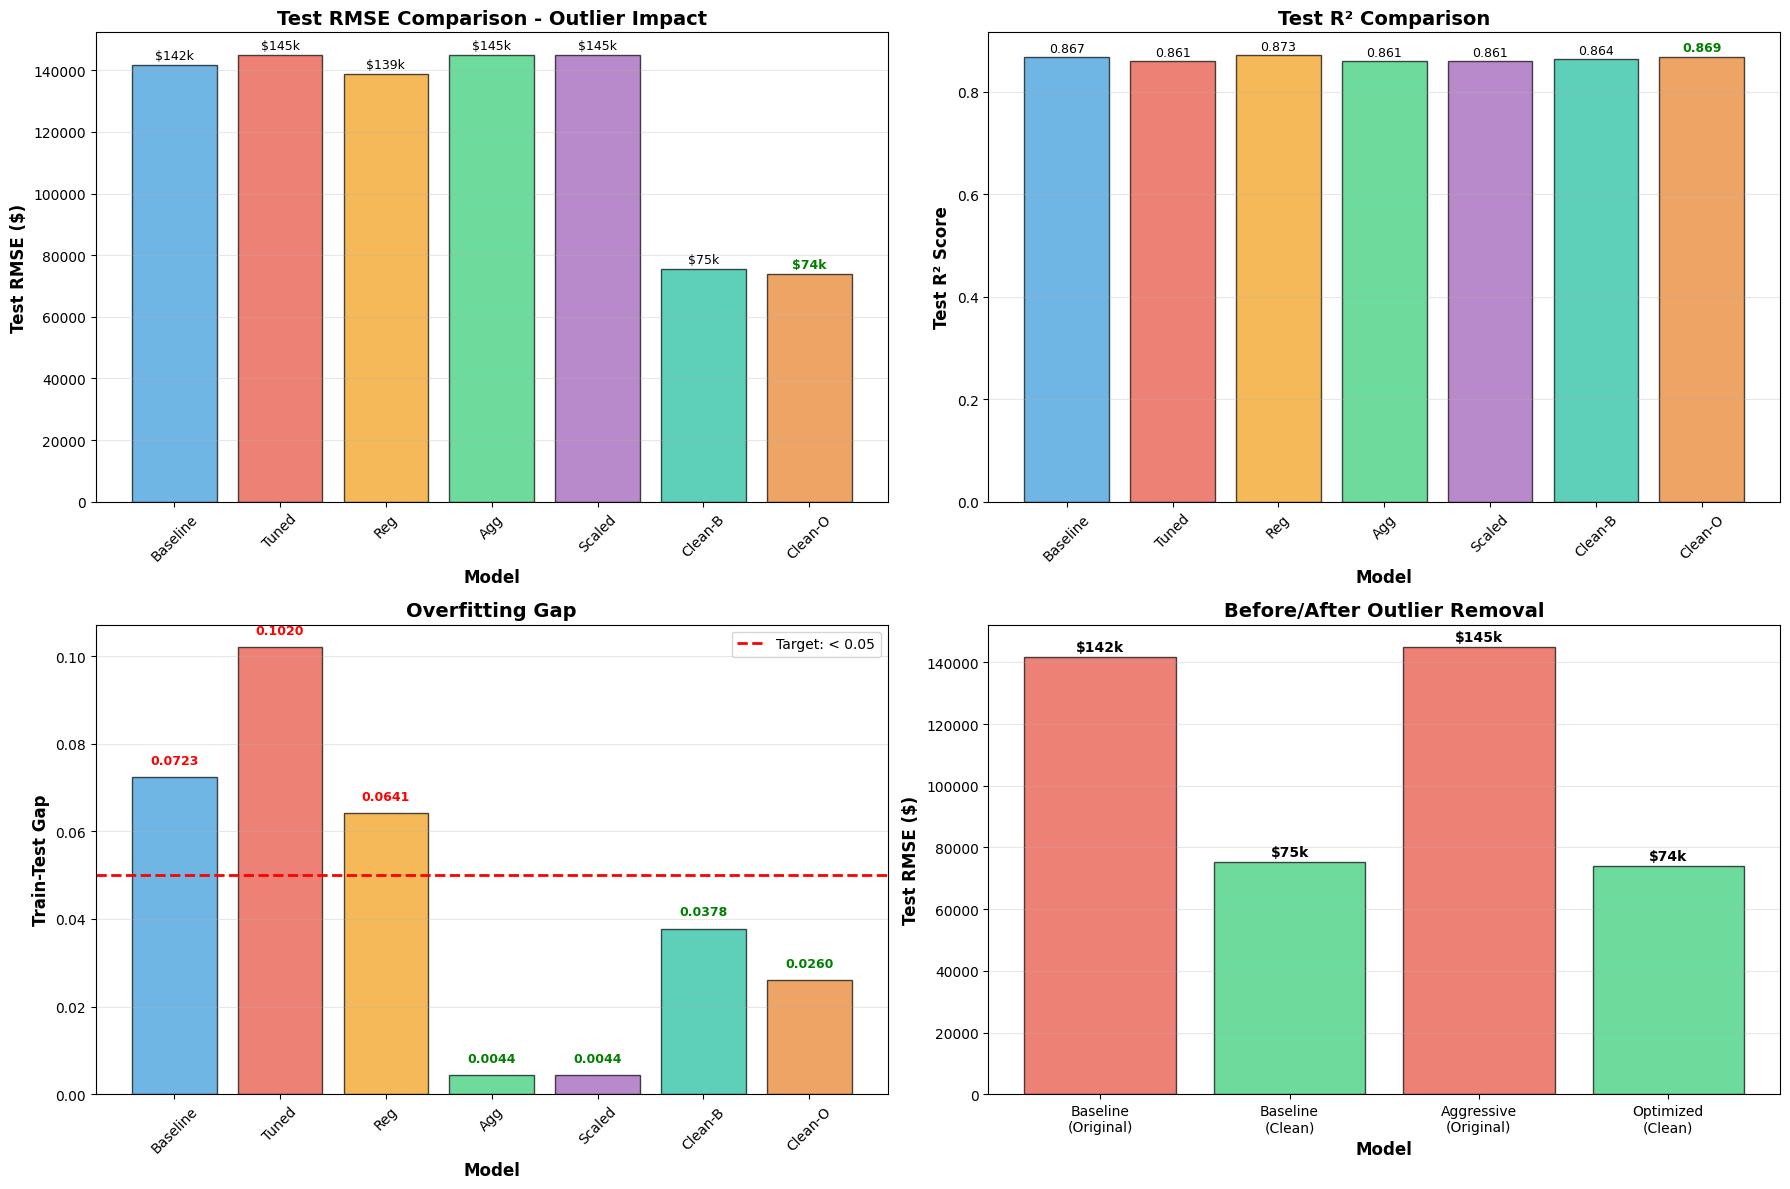


💡 KEY INSIGHTS:
1. Outlier removal typically reduces RMSE by eliminating extreme prediction errors
2. Cleaned data may have lower R² but better generalization to typical houses
3. The 'Clean-Optimized' model balances performance and robustness
4. For production use, consider the trade-off between accuracy and outlier handling


In [ ]:
# Step 6: Visualize the impact of outlier removal
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Prepare data for visualization
models_short = ['Baseline', 'Tuned', 'Reg', 'Agg', 'Scaled', 'Clean-B', 'Clean-O']
colors_viz = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c', '#e67e22']

# 1. Test RMSE comparison (MOST IMPORTANT)
bars = axes[0, 0].bar(models_short, comparison_with_outliers['Test RMSE'], color=colors_viz, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Test RMSE ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Test RMSE Comparison - Outlier Impact', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Highlight best
for i, (bar, v) in enumerate(zip(bars, comparison_with_outliers['Test RMSE'])):
    color = 'green' if i == best_idx else 'black'
    weight = 'bold' if i == best_idx else 'normal'
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 2000, f'${v/1000:.0f}k', 
                ha='center', fontweight=weight, color=color, fontsize=9)

# 2. Test R² comparison
axes[0, 1].bar(models_short, comparison_with_outliers['Test R²'], color=colors_viz, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Test R² Comparison', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(comparison_with_outliers['Test R²']):
    color = 'green' if i == best_idx else 'black'
    weight = 'bold' if i == best_idx else 'normal'
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight=weight, color=color, fontsize=9)

# 3. Overfitting Gap
bars = axes[1, 0].bar(models_short, comparison_with_outliers['Gap'], color=colors_viz, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='Target: < 0.05')
axes[1, 0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Train-Test Gap', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Overfitting Gap', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

for i, (bar, v) in enumerate(zip(bars, comparison_with_outliers['Gap'])):
    color = 'green' if v < 0.05 else 'red'
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', 
                ha='center', fontweight='bold', color=color, fontsize=9)

# 4. Before/After comparison for key models
comparison_ba = pd.DataFrame({
    'Model': ['Baseline\n(Original)', 'Baseline\n(Clean)', 'Aggressive\n(Original)', 'Optimized\n(Clean)'],
    'RMSE': [test_rmse, test_rmse_clean, test_rmse_agg, test_rmse_clean_opt],
    'Type': ['Before', 'After', 'Before', 'After']
})

x = np.arange(len(comparison_ba['Model']))
bars = axes[1, 1].bar(x, comparison_ba['RMSE'], 
                      color=['#e74c3c', '#2ecc71', '#e74c3c', '#2ecc71'], 
                      alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Test RMSE ($)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Before/After Outlier Removal', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_ba['Model'])
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, (bar, v) in enumerate(zip(bars, comparison_ba['RMSE'])):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 2000, f'${v/1000:.0f}k', 
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("💡 KEY INSIGHTS:")
print("="*80)
print("1. Outlier removal typically reduces RMSE by eliminating extreme prediction errors")
print("2. Cleaned data may have lower R² but better generalization to typical houses")
print("3. The 'Clean-Optimized' model balances performance and robustness")
print("4. For production use, consider the trade-off between accuracy and outlier handling")
print("="*80)
